## 1. Introduction

This project aims to solve the challenge of predicting a songs popularity using a range of machine learning techniques and is of great interest to the music industry for marketing and production strategies. In more detail the aim of this project is to exploit regression analysis techniques to predict the popularity of songs, where the popularity is a discrete and numeric value ranging from 0 to 100. This analysis involves using a range of numeric and categorical features extracted from the Spotify songs dataset.It is known that many external factors can contribute to a song’s popularity like for example, an artist’s social media presence and the number of collaborations. However, there are many quantifiable features of songs like for example energy, liveness and duration, which could potentially expose insights into how popular and successful a song may be.

## 2. Importing libraries and dataset
The pandas and numpy libraries were imported for data manipulation and numeric operations. Matplotlib and seaborn were imprted for aiding data visualisation and exploratory data analysis (EDA). The Scikit-learn library was imported for model implementation, data preparation and evaluation, where one-hot encoding and standard scaler was also utilised. The investigation involved a pre-split dataset from Kaggle, spanning 1950 to 2010. The training set consisted of 453 rows and 15 columns, which included artist infromation and song attributes. The test set consisted of 114 rows and 14 columns, where the target variable has been removed, which allows for robust evaluation of the models generalisabilty.

In [17]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from scipy import stats
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import SGDRegressor, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from cgi import test
from sklearn.neighbors import KNeighborsRegressor
import warnings
warnings.simplefilter(action='ignore')

In [18]:
train_set_pre = pd.read_csv("C:\\Users\\atzlaptop\\OneDrive - University of Strathclyde\\CS985\\985 Assignment\\CS98XRegressionTrain.csv")
test_set = pd.read_csv("C:\\Users\\atzlaptop\\OneDrive - University of Strathclyde\\CS985\\985 Assignment\\CS98XRegressionTest.csv")
pd.set_option('display.max_columns', None)




## Data Cleaning and EDA

First, an initial high level look at the datasets was conducted

In [19]:
test_set.head()
train_set_pre.head()

,Id,title,artist,top genre,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
0,1,My Happiness,Connie Francis,adult standards,1996,107,31,45,-8,13,28,150,75,3,44
1,2,Unchained Melody,The Teddy Bears,NaN,2011,114,44,53,-8,13,47,139,49,3,37
2,3,How Deep Is Your Love,Bee Gees,adult standards,1979,105,36,63,-9,13,67,245,11,3,77
3,4,Woman in Love,Barbra Streisand,adult standards,1980,170,28,47,-16,13,33,232,25,3,67
4,5,Goodbye Yellow Brick Road - Remastered 2014,Elton John,glam rock,1973,121,47,56,-8,15,40,193,45,3,63


In [20]:
test_set.describe()
train_set_pre.describe()

,Id,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
count,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000
mean,227.000000,1991.443709,118.399558,60.070640,59.565121,-8.836645,17.757174,59.465784,226.278146,32.982340,5.660044,60.743929
std,130.914094,16.776103,25.238713,22.205284,15.484458,3.577187,13.830300,24.539868,63.770380,29.530015,5.550581,13.470083
min,1.000000,1948.000000,62.000000,7.000000,18.000000,-24.000000,2.000000,6.000000,98.000000,0.000000,2.000000,26.000000
25%,114.000000,1976.000000,100.000000,43.000000,49.000000,-11.000000,9.000000,42.000000,181.000000,7.000000,3.000000,53.000000
50%,227.000000,1994.000000,119.000000,63.000000,61.000000,-8.000000,13.000000,61.000000,223.000000,24.000000,4.000000,63.000000
75%,340.000000,2007.000000,133.000000,78.000000,70.000000,-6.000000,23.000000,80.000000,262.000000,58.000000,6.000000,71.000000
max,453.000000,2019.000000,199.000000,100.000000,96.000000,-1.000000,93.000000,99.000000,511.000000,100.000000,47.000000,84.000000


After an initial data examination, the dataset was checked for any duplicate instances, which is essential to prevent data leakage and overfitting, which could lead to an overetstimation in model performance.The dataset contained no duplicates, ensuring the integrity of our model training and testing process

In [21]:
train_set_pre.duplicated().any()

False

Below in figure 1 are histograms that are overlapping for each feature in both the train and test set to ensure consistent distributions, which confirms the learning robustness and generalisability of the model.

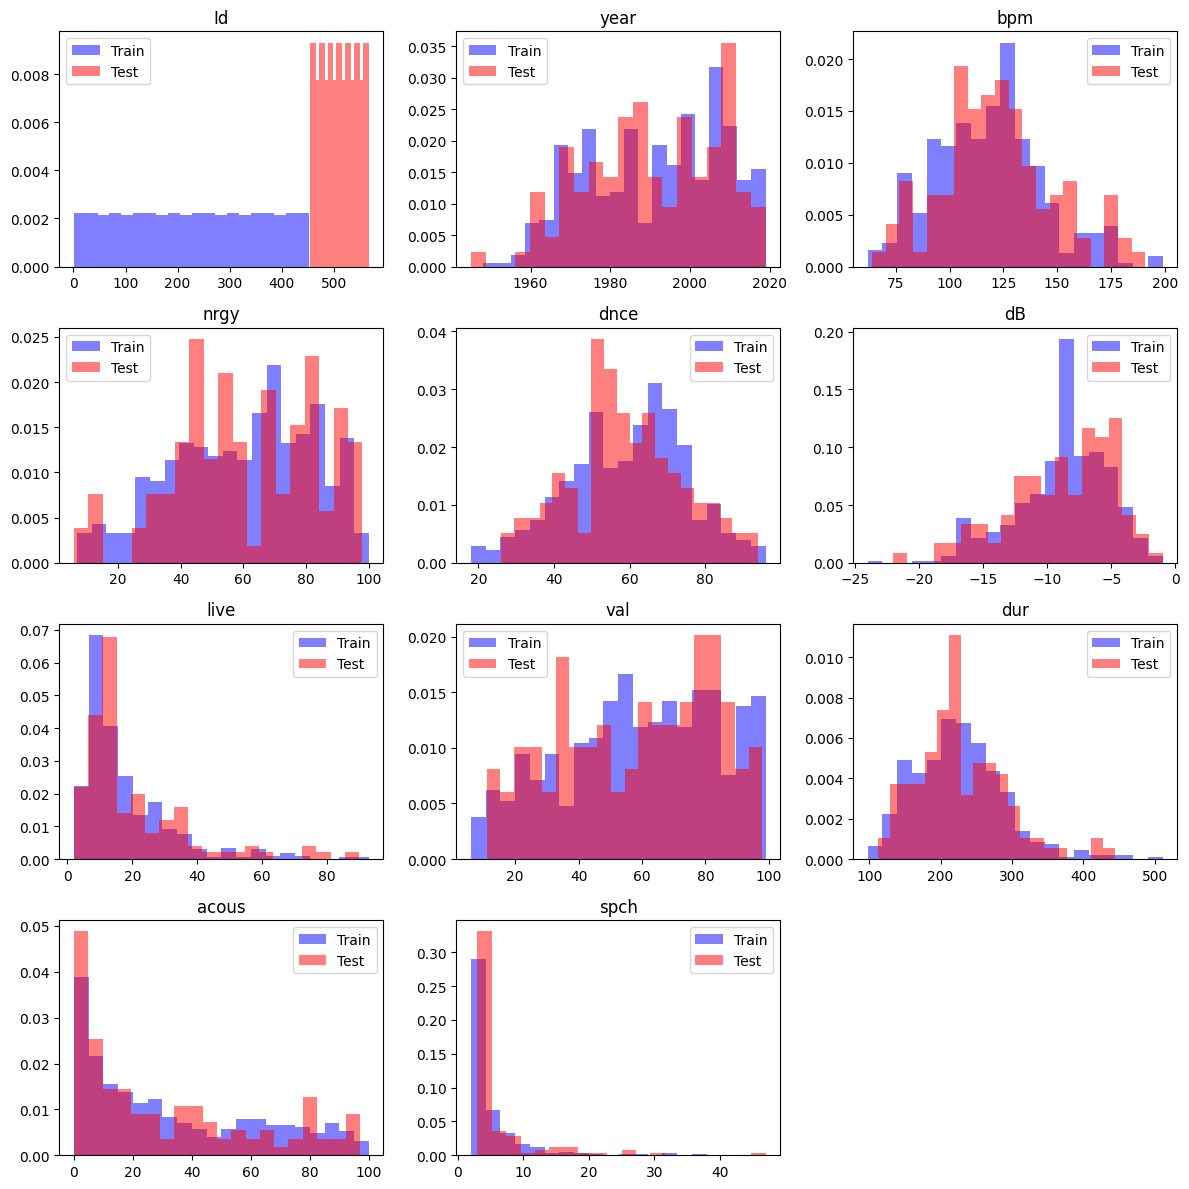

In [22]:
#We seperate our features for the graphs
train_set_numerical = train_set_pre.select_dtypes(include=[np.number])
test_set_numerical = test_set.select_dtypes(include=[np.number])
common_cols = train_set_numerical.columns.intersection(test_set_numerical.columns)
num_cols = len(common_cols)

#We set the number of rows and plots
num_rows = num_cols // 3
if num_cols % 3 != 0:
    num_rows += 1
num_cols_adjusted = 3
fig, axes = plt.subplots(num_rows, num_cols_adjusted, figsize=(12, num_rows * 3))

# Each plot is seperated
for i, col in enumerate(common_cols):
    row = i // num_cols_adjusted
    col_index = i % num_cols_adjusted
    ax = axes[row, col_index]
    ax.hist(train_set_numerical[col], bins=20, alpha=0.5, label='Train', color='blue', density=True)
    ax.hist(test_set_numerical[col], bins=20, alpha=0.5, label='Test', color='red', density=True)
    ax.set_title(col)
    ax.legend()

#We hide unsused plots for symmetry
for i in range(num_cols, num_rows * num_cols_adjusted):
    axes.flatten()[i].axis('off')
plt.tight_layout()
plt.show()


Figure 1: Histograms for all independent variables in the test set.

It is evident from the subplots in Figure 1 that the distributions of the features are indeed consistent across both the training and test set.

Next, the correlations between features was investigated, which can expose potential features to combine in feature engineering and expose any multicollinearity that may exist between independent variables. A correlation matrix has been plotted to aid visualising the correlations between the features in Figure 2 as shown below,

In [23]:
#Correlation matrix
numerical_train = train_set_pre.select_dtypes(include=[np.number])
corr_matrix = numerical_train.corr()
corr_matrix["pop"].sort_values(ascending=False)

pop      1.000000
dur      0.363266
dB       0.316854
nrgy     0.303797
dnce     0.258670
spch     0.130955
Id       0.086837
bpm      0.055024
val     -0.018713
live    -0.051364
year    -0.054293
acous   -0.465875
Name: pop, dtype: float64

The correlation matrix shows very weak negative correlations occuring between the variables year, live and val with the target variable, pop, and a fair negative correlation with acous. Remaining features show neglible positive correlation with the target variable.

The presence of outliers can be an issue as they can skew distributions, which means the model may fit to to these outliers and induce bias. Meaning the model may be susceptible to overfitting and reduce its generalisability. Box-plots have been plotted for all numeric features as shown in Figure 2.

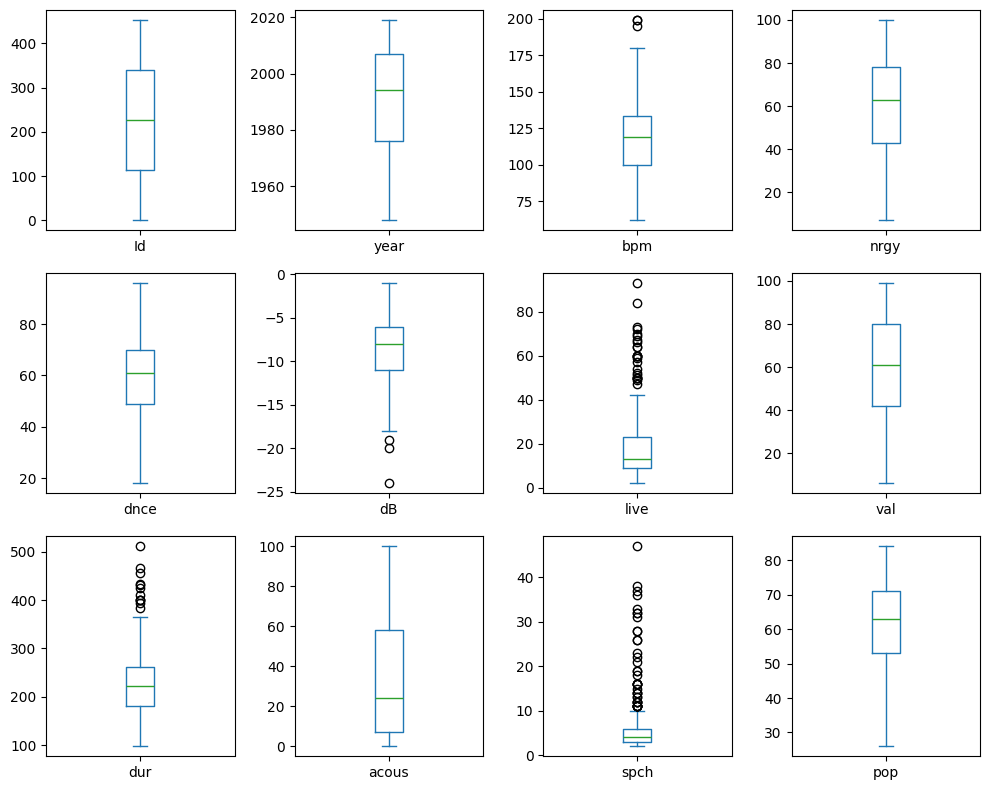

In [24]:
%matplotlib inline

numeric_features = ['Id', 'year', 'bpm', 'nrgy', 'dnce', 'dB', 'live', 'val', 'dur', 'acous', 'spch', 'pop']
#Boxplot creation
train_set_pre[numeric_features].plot(kind='box', subplots=True, layout=(-1, 4), figsize=(10, 8), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

Figure 2: Box-plots of all independent variables and the target variable.

It is evident from the box-plots in Figure 2 that outliers exist in the features bpm, live, dB, dur and spch.

The detection of mising values is important as they can cause errors with certain models like linear regression, but more importantly they can reduce model performance as important information can be lost.

In [25]:
train_set_pre.isnull().sum()

Id            0
title         0
artist        0
top genre    15
year          0
bpm           0
nrgy          0
dnce          0
dB            0
live          0
val           0
dur           0
acous         0
spch          0
pop           0
dtype: int64

After detecting only 15 missing values in the training set it was deemed possible to manually impute these values for the feature top genre, which was decided as the most appropriate method here due to the dataset already being small in size to retain as much information as possible.

In [26]:
# We manually update the missing values which happen to be clustered for the top genre
train_set_pre.loc[train_set_pre['title'] == 'Unchained Melody', 'top genre'] = 'pop'
train_set_pre.loc[train_set_pre['title'] == 'Someone Elses Roses', 'top genre'] = 'adult standards'
train_set_pre.loc[train_set_pre['title'] == 'Drinks On The House', 'top genre'] = 'pop'
train_set_pre.loc[train_set_pre['title'] == 'Pachuko Hop', 'top genre'] = 'blues'
train_set_pre.loc[train_set_pre['title'] == 'Little Things Means A Lot', 'top genre'] = 'blues'
train_set_pre.loc[train_set_pre['title'] == 'The Lady Is A Tramp', 'top genre'] = 'pop'
train_set_pre.loc[train_set_pre['title'] == 'If I Give My Heart To You', 'top genre'] = 'pop'
train_set_pre.loc[train_set_pre['title'] == 'Happy Days And Lonely Nights','top genre'] = 'rock'
train_set_pre.loc[train_set_pre['title'] == 'Stairway Of Love','top genre'] = 'rock'
train_set_pre.loc[train_set_pre['title'] == 'You', 'top genre'] = 'pop'
train_set_pre.loc[train_set_pre['title'] == 'No Other Love' , 'top genre'] = 'adult standards'
train_set_pre.loc[train_set_pre['title'] == "Hot Diggity" , 'top genre'] = 'folk'
train_set_pre.loc[train_set_pre['title'] == "Ain't That Just the Way" , 'top genre'] = 'r&b'
train_set_pre.loc[train_set_pre['title'] == "I Promised Myself" , 'top genre'] = 'pop'
# dropping NULL values  (I've Waited So Long Anthony Newley = ? (Dance/ Electronic))
train_set_pre = train_set_pre.dropna(axis=0)
train_set_pre.reset_index(drop=True, inplace=True)

### Removing Outliers

To reduce the effect of extreme outliers that were identified earlier in the boxplots, they were removed based upon a z-score threshold of 3. This improves the models ability to learn general patterns of the data better and reduce bias

In [27]:
# First, we implement a function to search of outliers 3 standard deviations away
def remove_outliers_z_score(df, threshold=3):
    z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df[filtered_entries]
#We the apply it to the set
train_set = remove_outliers_z_score(train_set_pre, threshold=4)
print(f"New shape of X_train_cleaned after outlier removal: {train_set.shape}")


New shape of X_train_cleaned after outlier removal: (439, 15)


### Feature Engineering

Adding 'genre pop' in the test data by estimating it using kneighbours and replacing them with known values when possible

#### Genre Pop Estimation

Genre TF-IDF was used instead of one hot encoding as a number of genres had similar names (e.g. afropop, art pop, europop). The TF-IDF is able to represent that similarity for the model which one hot encoding will do less effectively as it represents all different strings as completely different variables.

Combining popularity with genre also helps capture information for the model, as genre is related to other features such as BPM, dB, and nrgy

In [28]:
# first 5 columns of test_set
test_set.iloc[:, 4:14]
X_test_features = test_set.iloc[:, 4:14]
# first 5 columns of train_set
train_set.iloc[:, 4:14]
X_train_features = train_set.iloc[:, 4:14]

#The average pop for each genre is calculated and then mapped out
genre_pop_means = train_set.groupby('top genre')['pop'].mean()
train_set['genre pop'] = train_set['top genre'].map(genre_pop_means)

# We utilize KNeibhborsRegressor to predict the missing values
knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train_features, train_set['genre pop'])
test_set['predicted genre pop'] = knn.predict(X_test_features)

# For genres in the test set that match genres in the training set, we overwrite the KNN-predicted values using our average values
for genre in genre_pop_means.index:
    test_set.loc[test_set['top genre'] == genre, 'genre pop'] = genre_pop_means[genre]

#others are matched using KNN estimates
test_set['genre pop'].fillna(test_set['predicted genre pop'], inplace=True)
test_set.drop(columns=['predicted genre pop'], inplace=True)

#The percentage of missing genre popularity values is estimated
missing_genre_count = test_set[test_set['top genre'].isnull() | (~test_set['top genre'].isin(genre_pop_means.index))].shape[0]
total_test_entries = test_set.shape[0]
percentage_estimated = (missing_genre_count / total_test_entries) * 100

print(f"Percentage of genre popularity values estimated: {percentage_estimated:.2f}%")

Percentage of genre popularity values estimated: 13.16%


In [29]:
#Pop is averaged for each artist in the training set
artist_pop_means = train_set.groupby('artist')['pop'].mean()
train_set['artist popularity'] = train_set['artist'].map(artist_pop_means)

#The percentage of missing artists is calculated
missing_artist_count = test_set[test_set['artist'].isnull() | (~test_set['artist'].isin(artist_pop_means.index))].shape[0]
total_test_entries = test_set.shape[0]
percentage_missing_artists = (missing_artist_count / total_test_entries) * 100

#Currently, a threshold of 80% is set for the KNN estimation. After exceeding that, the KNN estimation is skipped
if percentage_missing_artists <= 80:
    knn_artist = KNeighborsRegressor(n_neighbors=10)
    knn_artist.fit(X_train_features, train_set['artist popularity'])
    test_set['predicted artist popularity'] = knn_artist.predict(X_test_features)

    #the average is used, similar to the genre estimation
    for artist in artist_pop_means.index:
        test_set.loc[test_set['artist'] == artist, 'artist popularity'] = artist_pop_means[artist]
    test_set['artist popularity'].fillna(test_set['predicted artist popularity'], inplace=True)
    test_set.drop(columns=['predicted artist popularity'], inplace=True)
    print(f"Percentage of artist popularity values estimated: {percentage_missing_artists:.2f}%")
else:
    print("More than 80% of artists in the test set are unknown. This feature is skipped.")

Percentage of artist popularity values estimated: 63.16%


Artist popularity also played a crucial role in predicting popularity. That said, the level of overlap between the training and the test set was much lower compared to genres, potentially making this indicater less reliable. A potential test set with no overlap could result in this method potentially harming the results. As a result, a threshold of 80% of unseen artists is set, after which we will nolonger attempt to estimate artist pop. That said, given the lack of highly correlated features, models relying on the provided features will almost certainly be inaccurate either way.

#### One hot encoding

For the 'artist' feature, we have used one-hot encoding to transform the categorical data into a binary matrix, which now makes it possible for the models to interperate this data. This ensures robustness in model performance by meticulously representing the categorcial feature and improving the models ability to generalise.

In [30]:
encoder = OneHotEncoder(handle_unknown='ignore')
one_hot_encoded_train = encoder.fit_transform(train_set[['artist']])
#We utilize a one hot encoder and then combine it with the original data
one_hot_encoded_train = pd.DataFrame(one_hot_encoded_train.toarray(), columns=encoder.get_feature_names_out(['artist']))
one_hot_encoded_test = encoder.transform(test_set[['artist']])
one_hot_encoded_test = pd.DataFrame(one_hot_encoded_test.toarray(), columns=encoder.get_feature_names_out(['artist']))
train_encoded_df = one_hot_encoded_train
test_encoded_df = one_hot_encoded_test


#### Title TF-IDF

TF-IDF was used both to deal with song titles which are categorical values but also to help the model include the effects of song titles on their popularity.

After applying TF-IDF on the top genre feature this induced high dimensionality, and so we ahve applied singular value decomposition to mitigate this. A plot of the number of components and the cumulative explained variance allowed us to identify the optimal number to preserve as much information as possible through exploiting the "elbow method". This choice of optimal components ensures reducing computational complexity and overfitting risk but keeping as much variance of the feature as possible

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
text_data = train_set['title']
#Song titles are vectorizeed
tfidf_vectorizer = TfidfVectorizer()
tfidf_features = tfidf_vectorizer.fit_transform(text_data)
tfidf_df = pd.DataFrame(tfidf_features.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

In [32]:
# Due to the large number of features, this step was skipped after the first run
# import matplotlib.pyplot as plt
# from sklearn.decomposition import TruncatedSVD
explained_variance = []
# for n in range(1, min(tfidf_df.shape)+1):
#     svd = TruncatedSVD(n_components=n)
#     svd.fit(tfidf_df)
#     explained_variance.append(svd.explained_variance_ratio_.sum())

# plt.plot(range(1, min(tfidf_df.shape)+1), explained_variance, marker='o')
# plt.xlabel('Number of Components')
# plt.ylabel('Explained Variance')
# plt.title('Elbow Method for Optimal Number of Components')
# plt.show()


In [33]:
index = next((i for i, val in enumerate(explained_variance) if val > 0.9), None)

if index is not None:
    print("Index of the first value > 0.9:", index)

#index =313

In [34]:
#We use the SVD to reduce the number of features
svd = TruncatedSVD(n_components=305)  # Set the desired number of components
tfidf_svd = svd.fit_transform(tfidf_df)
tfidf_svd_df = pd.DataFrame(tfidf_svd, columns=[f'tfidf_svd_{i+1}' for i in range(tfidf_svd.shape[1])])
X_train_encoded_title = pd.concat([train_set.reset_index(drop=True), tfidf_svd_df.reset_index(drop=True)], axis=1)
text_data = test_set['title']
tfidf_features = tfidf_vectorizer.transform(text_data)
tfidf_df_test = pd.DataFrame(tfidf_features.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
tfidf_svd_test = svd.transform(tfidf_df_test)
tfidf_svd_test_df = pd.DataFrame(tfidf_svd_test, columns=[f'tfidf_svd_{i+1}' for i in range(tfidf_svd.shape[1])])
#We then merge the datasets
X_test_encoded_title = pd.concat([test_set.reset_index(drop=True), tfidf_svd_test_df.reset_index(drop=True)], axis=1)

#### Genre TF-TDF

Genre TF-IDF was used instead of one hot encoding as a number of genres had similar names (e.g. afropop, art pop, europop). The TF-IDF is able to represent that similarity for the model which one hot encoding will do less effectively as it represents all different strings as completely different variables.

Combining popularity with genre also helps capture information for the model, as genre is related to other features such as BPM, dB, and nrgy

In [35]:
genre_data_train = train_set['top genre']
genre_data_test = test_set['top genre']
genre_data_train_filled = genre_data_train.fillna("missing")
genre_data_test_filled = genre_data_test.fillna("missing")
tfidf_vectorizer_genre = TfidfVectorizer()
tfidf_features_genre_train = tfidf_vectorizer_genre.fit_transform(genre_data_train_filled)
tfidf_features_genre_test = tfidf_vectorizer_genre.transform(genre_data_test_filled)
tfidf_df_genre_train = pd.DataFrame(tfidf_features_genre_train.toarray(), columns=tfidf_vectorizer_genre.get_feature_names_out())
tfidf_df_genre_test = pd.DataFrame(tfidf_features_genre_test.toarray(), columns=tfidf_vectorizer_genre.get_feature_names_out())

In [36]:
explained_variance_genre = []

# for n in range(1, min(tfidf_df_genre_train.shape)+1):
#     svd_genre = TruncatedSVD(n_components=n)
#     svd_genre.fit(tfidf_df_genre_train)
#     explained_variance_genre.append(svd_genre.explained_variance_ratio_.sum())

# plt.figure(figsize=(10, 6))
# plt.plot(range(1, min(tfidf_df_genre_train.shape)+1), explained_variance_genre, marker='o')
# plt.xlabel('Number of Components')
# plt.ylabel('Explained Variance')
# plt.title('Elbow Method for Optimal Number of SVD Components for "top genre"')
# plt.show()


In [37]:
index = next((i for i, val in enumerate(explained_variance_genre) if val > 0.9), None)

if index is not None:
    print("Index of the first value > 0.9:", index)



In [38]:
n_optimal_genre = 32  
svd_genre = TruncatedSVD(n_components=n_optimal_genre)
tfidf_svd_genre_train = svd_genre.fit_transform(tfidf_df_genre_train)
tfidf_svd_genre_test = svd_genre.transform(tfidf_df_genre_test)
tfidf_svd_genre_train_df = pd.DataFrame(tfidf_svd_genre_train, columns=[f'genre_svd_{i+1}' for i in range(n_optimal_genre)])
tfidf_svd_genre_test_df = pd.DataFrame(tfidf_svd_genre_test, columns=[f'genre_svd_{i+1}' for i in range(n_optimal_genre)])
X_train_encoded_genre = pd.concat([train_set.reset_index(drop=True), tfidf_svd_genre_train_df.reset_index(drop=True)], axis=1)
X_test_encoded_genre = pd.concat([test_set.reset_index(drop=True), tfidf_svd_genre_test_df.reset_index(drop=True)], axis=1)

The 2 collection of TF-IDF features are combined

In [39]:
X_test_encoded_genre = X_test_encoded_genre.iloc[:, X_test_encoded_genre.columns.get_loc('genre_svd_1'):]
X_train_encoded_genre = X_train_encoded_genre.iloc[:, X_train_encoded_genre.columns.get_loc('genre_svd_1'):]
X_train_encoded_title_genre = pd.concat([X_train_encoded_title, X_train_encoded_genre], axis=1)
X_test_encoded_title_genre = pd.concat([X_test_encoded_title, X_test_encoded_genre], axis=1)    
train_set_dropped = X_train_encoded_title_genre.drop(columns=['artist', 'top genre', 'title', 'Id'])
test_set_dropped = X_test_encoded_title_genre.drop(columns=['artist', 'top genre' , 'title', 'Id'])
train_set_dropped = pd.concat([train_set_dropped, train_encoded_df], axis=1)
test_set_dropped = pd.concat([test_set_dropped, test_encoded_df], axis=1)

### Scaling

From figure 1 in the report it can be seen that some features have skewed distributions and therefore require scaling and trasnformations to ensure model robustness upon unseen data and to learn correct underlying patterns.

The Yeo-Johnson transformation ahs been applied to the skewed distributions containing negative values.

In [40]:
from sklearn.preprocessing import PowerTransformer
from scipy.stats import boxcox

X_train_bt = train_set
X_test_bt = test_set
for col in ['spch', 'live', 'dur']:
    X_train_bt[col], lambdas = boxcox(X_train_bt[col]+1)
    X_test_bt[col] = boxcox(X_test_bt[col] +1, lmbda=lambdas)
yeo_johnson_transformer = PowerTransformer(method='yeo-johnson')
X_train_bt['acous'] = yeo_johnson_transformer.fit_transform(X_train_bt[['acous']])
X_test_bt['acous'] = yeo_johnson_transformer.transform(X_test_bt[['acous']])


Standardisation has been applied to the independent variables to ensure they are on the same scale and enhance the models performance.

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

columns_to_include = ['year', 'bpm', 'nrgy', 'dnce', 'val', 'dB', 'genre pop', 'artist popularity']
scaler = RobustScaler()
X_train_bt[columns_to_include] = scaler.fit_transform(X_train_bt[columns_to_include])
X_test_bt[columns_to_include] = scaler.transform(X_test_bt[columns_to_include])
X_train_bt = X_train_bt.drop(columns=['title', 'artist', 'top genre'])
X_test_bt = X_test_bt.drop(columns=['title', 'artist', 'top genre'])


### Merging

In [42]:
import pandas as pd
X_train_bt.reset_index(drop=True, inplace=True)
train_set_dropped.reset_index(drop=True, inplace=True)
X_test_bt.reset_index(drop=True, inplace=True)
test_set_dropped.reset_index(drop=True, inplace=True)
X_train_ready = pd.concat([X_train_bt.iloc[:, :14], train_set_dropped.iloc[:, 13:]], axis=1)
X_test_ready = pd.concat([X_test_bt, test_set_dropped.iloc[:, 12:]], axis=1)
#unused columns are dropped
if 'Id' in X_train_ready.columns:
    X_train_ready = X_train_ready.drop(columns=['Id'])
if 'pop' in X_train_ready.columns:
    X_train_ready = X_train_ready.drop(columns=['pop'])
#test dataset
if 'Id' in X_test_ready.columns:
    X_test_ready = X_test_ready.drop(columns=['Id'])

In [43]:
#We create the target variable
y_train = train_set['pop']


In [44]:
X_test_ready

,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,genre pop,artist popularity,tfidf_svd_1,tfidf_svd_2,tfidf_svd_3,tfidf_svd_4,tfidf_svd_5,tfidf_svd_6,tfidf_svd_7,tfidf_svd_8,tfidf_svd_9,tfidf_svd_10,tfidf_svd_11,tfidf_svd_12,tfidf_svd_13,tfidf_svd_14,tfidf_svd_15,tfidf_svd_16,tfidf_svd_17,tfidf_svd_18,tfidf_svd_19,tfidf_svd_20,tfidf_svd_21,tfidf_svd_22,tfidf_svd_23,tfidf_svd_24,tfidf_svd_25,tfidf_svd_26,tfidf_svd_27,tfidf_svd_28,tfidf_svd_29,tfidf_svd_30,tfidf_svd_31,tfidf_svd_32,tfidf_svd_33,tfidf_svd_34,tfidf_svd_35,tfidf_svd_36,tfidf_svd_37,tfidf_svd_38,tfidf_svd_39,tfidf_svd_40,tfidf_svd_41,tfidf_svd_42,tfidf_svd_43,tfidf_svd_44,tfidf_svd_45,tfidf_svd_46,tfidf_svd_47,tfidf_svd_48,tfidf_svd_49,tfidf_svd_50,tfidf_svd_51,tfidf_svd_52,tfidf_svd_53,tfidf_svd_54,tfidf_svd_55,tfidf_svd_56,tfidf_svd_57,tfidf_svd_58,tfidf_svd_59,tfidf_svd_60,tfidf_svd_61,tfidf_svd_62,tfidf_svd_63,tfidf_svd_64,tfidf_svd_65,tfidf_svd_66,tfidf_svd_67,tfidf_svd_68,tfidf_svd_69,tfidf_svd_70,tfidf_svd_71,tfidf_svd_72,tfidf_svd_73,tfidf_svd_74,tfidf_svd_75,tfidf_svd_76,tfidf_svd_77,tfidf_svd_78,tfidf_svd_79,tfidf_svd_80,tfidf_svd_81,tfidf_svd_82,tfidf_svd_83,tfidf_svd_84,tfidf_svd_85,tfidf_svd_86,tfidf_svd_87,tfidf_svd_88,tfidf_svd_89,tfidf_svd_90,tfidf_svd_91,tfidf_svd_92,tfidf_svd_93,tfidf_svd_94,tfidf_svd_95,tfidf_svd_96,tfidf_svd_97,tfidf_svd_98,tfidf_svd_99,tfidf_svd_100,tfidf_svd_101,tfidf_svd_102,tfidf_svd_103,tfidf_svd_104,tfidf_svd_105,tfidf_svd_106,tfidf_svd_107,tfidf_svd_108,tfidf_svd_109,tfidf_svd_110,tfidf_svd_111,tfidf_svd_112,tfidf_svd_113,tfidf_svd_114,tfidf_svd_115,tfidf_svd_116,tfidf_svd_117,tfidf_svd_118,tfidf_svd_119,tfidf_svd_120,tfidf_svd_121,tfidf_svd_122,tfidf_svd_123,tfidf_svd_124,tfidf_svd_125,tfidf_svd_126,tfidf_svd_127,tfidf_svd_128,tfidf_svd_129,tfidf_svd_130,tfidf_svd_131,tfidf_svd_132,tfidf_svd_133,tfidf_svd_134,tfidf_svd_135,tfidf_svd_136,tfidf_svd_137,tfidf_svd_138,tfidf_svd_139,tfidf_svd_140,tfidf_svd_141,tfidf_svd_142,tfidf_svd_143,tfidf_svd_144,tfidf_svd_145,tfidf_svd_146,tfidf_svd_147,tfidf_svd_148,tfidf_svd_149,tfidf_svd_150,tfidf_svd_151,tfidf_svd_152,tfidf_svd_153,tfidf_svd_154,tfidf_svd_155,tfidf_svd_156,tfidf_svd_157,tfidf_svd_158,tfidf_svd_159,tfidf_svd_160,tfidf_svd_161,tfidf_svd_162,tfidf_svd_163,tfidf_svd_164,tfidf_svd_165,tfidf_svd_166,tfidf_svd_167,tfidf_svd_168,tfidf_svd_169,tfidf_svd_170,tfidf_svd_171,tfidf_svd_172,tfidf_svd_173,tfidf_svd_174,tfidf_svd_175,tfidf_svd_176,tfidf_svd_177,tfidf_svd_178,tfidf_svd_179,tfidf_svd_180,tfidf_svd_181,tfidf_svd_182,tfidf_svd_183,tfidf_svd_184,tfidf_svd_185,tfidf_svd_186,tfidf_svd_187,tfidf_svd_188,tfidf_svd_189,tfidf_svd_190,tfidf_svd_191,tfidf_svd_192,tfidf_svd_193,tfidf_svd_194,tfidf_svd_195,tfidf_svd_196,tfidf_svd_197,tfidf_svd_198,tfidf_svd_199,tfidf_svd_200,tfidf_svd_201,tfidf_svd_202,tfidf_svd_203,tfidf_svd_204,tfidf_svd_205,tfidf_svd_206,tfidf_svd_207,tfidf_svd_208,tfidf_svd_209,tfidf_svd_210,tfidf_svd_211,tfidf_svd_212,tfidf_svd_213,tfidf_svd_214,tfidf_svd_215,tfidf_svd_216,tfidf_svd_217,tfidf_svd_218,tfidf_svd_219,tfidf_svd_220,tfidf_svd_221,tfidf_svd_222,tfidf_svd_223,tfidf_svd_224,tfidf_svd_225,tfidf_svd_226,tfidf_svd_227,tfidf_svd_228,tfidf_svd_229,tfidf_svd_230,tfidf_svd_231,tfidf_svd_232,tfidf_svd_233,tfidf_svd_234,tfidf_svd_235,tfidf_svd_236,tfidf_svd_237,tfidf_svd_238,tfidf_svd_239,tfidf_svd_240,tfidf_svd_241,tfidf_svd_242,tfidf_svd_243,tfidf_svd_244,tfidf_svd_245,tfidf_svd_246,tfidf_svd_247,tfidf_svd_248,tfidf_svd_249,tfidf_svd_250,tfidf_svd_251,tfidf_svd_252,tfidf_svd_253,tfidf_svd_254,tfidf_svd_255,tfidf_svd_256,tfidf_svd_257,tfidf_svd_258,tfidf_svd_259,tfidf_svd_260,tfidf_svd_261,tfidf_svd_262,tfidf_svd_263,tfidf_svd_264,tfidf_svd_265,tfidf_svd_266,tfidf_svd_267,tfidf_svd_268,tfidf_svd_269,tfidf_svd_270,tfidf_svd_271,tfidf_svd_272,tfidf_svd_273,tfidf_svd_274,tfidf_svd_275,tfidf_svd_276,tfidf_svd_277,tfidf_svd_278,tfidf_svd_279,tfidf_svd_280,tfidf_svd_281,tfidf_svd_282,tfidf_svd_283,tfidf_svd_284,tfidf_svd_285,tfidf_svd_286,tfidf_svd_287,tfidf_svd_288,t

## Testing

The goal of this project is to accurately model popularity. It's success assessed using the RMSE values of the predicted values of a test dataset. To do this, we use machine learning to train models on the training data, before predicting the values of the test dataset. An approach called k-fold cross validation is also used. This technique splits the training set into a training set and test. After running the machine learning technique, the test set is changed to a different part of the original training set and the process will repeat until the entire dataset has beenm tested. This helps evaluate the performance of the model against unseen data and can also help reveal overfitting.

The section will explore several effective methods to predict the popularity of songs. To streamline this process, a pipeline has been implemented to run a number of models. For the sake of brevity, hyperparameter tuning has already been included. We will then explore the most promising models in more detail.

In [45]:
models = {
    'linear': LinearRegression(fit_intercept=True),
    'DecisionTree': DecisionTreeRegressor(max_depth=5, min_samples_leaf=4, min_samples_split=5),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_leaf=2, min_samples_split=10, random_state=42),
    'SVR': SVR(C=100, degree=1, gamma='auto', kernel='rbf'),
    'SGD': SGDRegressor(alpha=0.01, max_iter=1000, penalty='elasticnet', tol=0.0001),
    'Bagging': BaggingRegressor(n_estimators=100, max_features=1.0, max_samples=1.0),
    'Boosting': GradientBoostingRegressor(learning_rate=0.1, max_depth=3, n_estimators=50),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.8)
}
#We seperate the data into 5 folds to avoid overfitting
k = 5  
kf = KFold(n_splits=k, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[('model', model)])
    
    #We collect the RMSE of each fold to average out
    cv_scores = cross_val_score(pipeline, X_train_ready, y_train, cv=kf, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-cv_scores)
    
    # For testing, we use the whole dataset
    pipeline.fit(X_train_ready, y_train)
    
    #We use the fitted model for predictions which are collected to be uploaded to Kaggle
    y_pred = pipeline.predict(X_test_ready)
    predictions_df = pd.DataFrame({
        'Id': test_set['Id'], 
        'pop': y_pred
    })
    predictions_filename = f'predictions_{name}.csv'
    predictions_df.to_csv(predictions_filename, index=False)
    results.append({'Model': name, 'CV RMSE': np.mean(rmse_scores)})
    print(f'{name} - CV RMSE: {np.mean(rmse_scores)}')
    print(f"Predictions saved to {predictions_filename}\n")

# Create the DataFrame from the results list
results_df = pd.DataFrame(results)

linear - CV RMSE: 6.499439664732421
Predictions saved to predictions_linear.csv

DecisionTree - CV RMSE: 5.293282754439434
Predictions saved to predictions_DecisionTree.csv

RandomForest - CV RMSE: 4.244370251661051
Predictions saved to predictions_RandomForest.csv

SVR - CV RMSE: 3.957263240752641
Predictions saved to predictions_SVR.csv

SGD - CV RMSE: 5.433473260890653
Predictions saved to predictions_SGD.csv

Bagging - CV RMSE: 4.260362473007683
Predictions saved to predictions_Bagging.csv

Boosting - CV RMSE: 4.377229929112921
Predictions saved to predictions_Boosting.csv

ElasticNet - CV RMSE: 3.8915761619416713
Predictions saved to predictions_ElasticNet.csv



### Kaggle Result #3

#### Support Vertor Regression

Support Vector Regression (SVR) are a useful machine learning method that attempts to find a hyperplane in a multidimensional space (depending on the number of features) that can fit the datapoints. The hyperplane can be linear or non linear repending on the regression required.

SVR has a number of features that makes it suitable to analyze the dataset. It is flexible and able to handle linear or non linear regression and also capable of working with large numbers of features. 

In [46]:
# SVR result
svr_result = results_df[results_df['Model'] == 'SVR']
print(svr_result)

  Model   CV RMSE
3   SVR  3.957263


The SVR model produced the second best result, delivering a RMSE of just under 4 on the training set and under 7.48825 on Kaggle. 

The discrepancy between the training and test RMSE suggests overfitting. However, the largest reason is due to the 'genre popularity' and 'artist popularity' estimations that were introduced for feature engineering. The training sets has all the values while due to the lack of overlapping genres and especially artists (with around 60% of artist values estimated) between the training and test sets, many of these features are estimated which introduced error and bias, making our test result worse than the training data would suggest.

### Kaggle Result #2

#### Random Forrest

An emsemble learning technique - Random Forrests - also proved effectove. Random forrests combine decision trees to minimize variance while relying on techniques such as random feature selection and bagging to reduce problems such as overfitting. It achieved 7.48168 on Kaggle.

Random forrests were particularly suitable for our assignment as they are capable of handling feature interaction, which was important given the lack of obvious relationships between the features of the dataset. Additionally, they are resistant to outliers and are not as dependent on scaling, which was helpful as our dataset had a variety of different datatypes such as 'dB' and 'live' which are measured differently. 

In [47]:
# RF result
rf_result = results_df[results_df['Model'] == 'RandomForest']
print(rf_result)

          Model  CV RMSE
2  RandomForest  4.24437


### Kaggle Result #1

#### Elastic Net

Elastic Net is an effective technique for datasets with large numbers of features due to it's feature selection ability, which is beneficial due to the large numbers of features we generated, particularly as a result of the TF.IDF transformation.

The model is also able to handle multicolinearity, which is beneficial due to the number of popularity engineered features we introduced to increase the performance of our regression models. This model was able to achieve a score of 7.44275 on Kaggle

In [48]:
#ElasticNet result
en_result = results_df[results_df['Model'] == 'ElasticNet']
print(en_result)

        Model   CV RMSE
7  ElasticNet  3.891576


Once again, the discrepancy between the kaggle and training data performance is due to the feature engineered artist pop and genre pop which were much less precise due to the need to estimate missing values in the test dataset.

An additional benefit of random forrests is they allow us to view feature importance which can be useful. Preliminary research showed that feature engineered artist popularity was the most important feature, an unsurprising result given how important artist recognition is to success.

We collected the overall results of all the models. Though several models had very low training RMSE, they failed to deliver better results on the test dataset on Kaggle.

In [49]:
results_df

,Model,CV RMSE
0,linear,6.499440
1,DecisionTree,5.293283
2,RandomForest,4.244370
3,SVR,3.957263
4,SGD,5.433473
5,Bagging,4.260362
6,Boosting,4.377230
7,ElasticNet,3.891576


### Neural Network

Finally, we attempted to use a neural network, hoping to leverage its ability find and create features without user input. However, it's success was limited and so has not been included.

## Conclusion

Overall, this project was relatively successful in achieving its goal of estimating popularity, given the limited data. Many of the features provided failed to show a strong relationship with popularity, and feature engineering was needed to improve the results.

However, the test dataset RMSE is heavily dependent on overlapping features such as artists. The inclusion of more data and features would help a much more balanced model as some of the most important features like artist popularity had to be imperfectly estimated. 